In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from scipy.interpolate import griddata
import os
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Chemins
# -------------------------------------------------------------------
SAVE_DIR     = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/'
CATALOGUE_NC = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_composites_ONI_sp.nc'
ERSST_PATH   = '/g/data/m35/qr1706/PhD-1_CMIP_analysis/data uploaded/ersstv5.nc'  
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------------------------------------------
# Chemins bruts CMIP6
# -------------------------------------------------------------------
cmip6_models = {
    'EC-Earth3':        '/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Omon/tos/gn/v20200918/',
    'EC-Earth3-Veg-LR': '/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200919/',
    'ACCESS-ESM1-5':    '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Omon/tos/gn/latest/',
    'SAMO-UNICON':      '/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Omon/tos/gn/v20190910/',
    'GFDL-ESM4':        '/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Omon/tos/gr/v20180701/',
    'GFDL-CM4':         '/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Omon/tos/gr/v20190201/',
    'NorESM2-MM':       '/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Omon/tos/gn/v20191108/',
    'MRI-ESM2-0':       '/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Omon/tos/gn/v20190904/',
    'UKESM1-0-LL':      '/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/tos/gn/v20200828/',
    'HadGEM3-GC31-LL':  '/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Omon/tos/gn/v20190628/',
}

print('Imports OK')

Imports OK


In [9]:
# Le NetCDF contient uniquement les composites ONI 36 mois.
# On s'en sert pour connaître la liste des modèles qui ont des TLN détectés.
ds_cat = xr.open_dataset(CATALOGUE_NC)
models_in_catalogue = list(ds_cat['model'].values)
print('Modèles dans le catalogue ONI :')
for m in models_in_catalogue:
    print(f'  {m}')

Modèles dans le catalogue ONI :
  EC-Earth3
  EC-Earth3-Veg-LR
  IPSL-CM6A-LR
  ACCESS-ESM1-5
  SAMO-UNICON
  NorESM2-MM
  NorESM2-LM
  GFDL-ESM4
  GFDL-CM4
  MRI-ESM2-0
  UKESM1-0-LL
  HadGEM3-GC31-LL


In [10]:
def get_oni_noaa_style_piControl(da_weighted_mean):
    """Calcule l'ONI selon la méthodologie NOAA (30 ans glissants)."""
    anomalies = []
    time_coord   = da_weighted_mean.time
    all_years    = time_coord.dt.year.values
    unique_years = np.unique(all_years)
    first_yr, last_yr = unique_years[0], unique_years[-1]
    current_last_yr   = first_yr

    for yr in range(first_yr + 15, last_yr - 14, 5):
        mask_period = (all_years >= yr) & (all_years <= yr + 4)
        mask_base   = (all_years >= yr - 15) & (all_years <= yr + 14)
        data_slice  = da_weighted_mean.isel(time=mask_period)
        base_slice  = da_weighted_mean.isel(time=mask_base)
        if data_slice.size >= 60 and base_slice.size >= 360:
            anom = (data_slice.groupby('time.month') -
                    base_slice.groupby('time.month').mean('time'))
            anomalies.append(anom)
            current_last_yr = yr + 4

    if last_yr > current_last_yr:
        remainder_mask = (all_years > current_last_yr)
        base_end_mask  = (all_years >= last_yr - 30) & (all_years <= last_yr)
        data_remainder = da_weighted_mean.isel(time=remainder_mask)
        base_end       = da_weighted_mean.isel(time=base_end_mask)
        if data_remainder.size > 0 and base_end.size >= 360:
            anom_end = (data_remainder.groupby('time.month') -
                        base_end.groupby('time.month').mean('time'))
            anomalies.append(anom_end)

    if not anomalies:
        return None
    all_anom = xr.concat(anomalies, dim='time').sortby('time')
    all_anom = all_anom.sel(time=~all_anom.get_index('time').duplicated())
    return all_anom.rolling(time=3, center=True).mean().round(2)


def identify_triples_final(oni_da):
    """Identifie les Triple La Niña (seuil relatif 0.5×STD)."""
    std_val         = float(oni_da.std())
    threshold       = -0.5 * std_val
    is_lanina_month = (oni_da <= threshold)

    lanina_years = []
    all_years    = np.unique(oni_da['time.year'])
    for yr in all_years[:-1]:
        mask_enso = ((oni_da['time.year'] == yr)     & (oni_da['time.month'] >= 6)) | \
                    ((oni_da['time.year'] == yr + 1) & (oni_da['time.month'] <= 5))
        sub = is_lanina_month.where(mask_enso, drop=True)
        if len(sub) >= 12 and (sub.rolling(time=5).sum() >= 5).any():
            peak_months = [11, 12, 1, 2, 3]
            if is_lanina_month.where(
                mask_enso & oni_da['time.month'].isin(peak_months), drop=True
            ).any():
                lanina_years.append(int(yr))

    triple_starts = []
    lanina_years  = sorted(set(lanina_years))
    for i in range(len(lanina_years) - 2):
        y0, y1, y2 = lanina_years[i], lanina_years[i+1], lanina_years[i+2]
        if (y1 == y0 + 1) and (y2 == y0 + 2):
            if (y0 - 1) not in lanina_years:
                triple_starts.append(y0)
    return triple_starts

print('Fonctions définies.')

Fonctions définies.


In [11]:
# Grille cible 1°×1° pour la MMM (sections 7-9)
lat_common = np.arange(-60, 60.5, 1.0)
lon_common = np.arange(0, 360, 1.0)

all_sst_composites = {}   # {model: DataArray [offset=3, lat, lon]} – grille native
all_tln_years      = {}   # {model: [yr0, yr1, ...]} – années de début

print(f'Démarrage du traitement pour {len(cmip6_models)} modèles...\n')

for name, path in cmip6_models.items():

    if name not in models_in_catalogue:
        print(f'[SKIP] {name} : absent du catalogue ONI.')
        continue
    if not os.path.exists(path):
        print(f'[SKIP] {name} : dossier introuvable.')
        continue

    print(f'--- {name} ---')
    try:
        ds = xr.open_mfdataset(
            path + '*.nc',
            combine='by_coords',
            chunks={'time': 240},
            use_cftime=True
        )

        # ── A. Coordonnées lat/lon ────────────────────────────────────
        lat_n = next((c for c in ['nav_lat', 'lat', 'latitude']  if c in ds.coords or c in ds.data_vars), None)
        lon_n = next((c for c in ['nav_lon', 'lon', 'longitude'] if c in ds.coords or c in ds.data_vars), None)
        if not lat_n or not lon_n:
            print('  Coordonnées introuvables → skip.')
            ds.close(); continue

        # ── B. ONI → années TLN ──────────────────────────────────────
        lon_max  = float(ds[lon_n].max())
        l1, l2   = (190, 240) if lon_max > 180 else (-170, -120)
        mask_n34 = ((ds[lat_n] >= -5) & (ds[lat_n] <= 5) &
                    (ds[lon_n] >= l1) & (ds[lon_n] <= l2)).compute()

        spatial_dims = [d for d in ds.tos.dims if d != 'time']
        weights = (np.cos(np.deg2rad(ds[lat_n])) if 'area' not in ds.data_vars
                   else ds.area).where(mask_n34).fillna(0)

        ts  = ds.tos.where(mask_n34).weighted(weights).mean(dim=spatial_dims).compute()
        oni = get_oni_noaa_style_piControl(ts)
        if oni is None:
            print('  ONI non calculé → skip.')
            ds.close(); continue

        triples = identify_triples_final(oni)
        all_tln_years[name] = triples
        print(f'  TLN : {len(triples)} événement(s) → {triples}')

        if len(triples) == 0:
            ds.close(); continue

        # ── C. SST – masque latitudinal 60°S–60°N ────────────────────
        mask_lat = ((ds[lat_n] >= -60) & (ds[lat_n] <= 60)).compute()
        ds_tos   = ds.tos.where(mask_lat, drop=True)
        if float(ds_tos.isel(time=0).mean().compute()) > 100:
            ds_tos = ds_tos - 273.15   # K → °C

        # ── D. Climatologie mensuelle ─────────────────────────────────
        clim_monthly = ds_tos.groupby('time.month').mean('time').compute()
        djf_clim = (clim_monthly.sel(month=12) +
                    clim_monthly.sel(month=1)  +
                    clim_monthly.sel(month=2)) / 3.0

        # ── E. Composite DJF par événement ───────────────────────────
        # Offset 0 → DJF de l'Année 1  (Déc yr+0, Jan-Fév yr+1)
        # Offset 1 → DJF de l'Année 2  (Déc yr+1, Jan-Fév yr+2)
        # Offset 2 → DJF de l'Année 3  (Déc yr+2, Jan-Fév yr+3)
        event_composites = []
        for yr in triples:
            offset_maps = []
            ok = True
            for off in range(3):
                dec_yr = yr + off
                jan_yr = yr + off + 1
                try:
                    dec_m = ds_tos.sel(time=(ds_tos['time.year'] == dec_yr) &
                                           (ds_tos['time.month'] == 12)).mean('time').compute()
                    jan_m = ds_tos.sel(time=(ds_tos['time.year'] == jan_yr) &
                                           (ds_tos['time.month'] == 1)).mean('time').compute()
                    feb_m = ds_tos.sel(time=(ds_tos['time.year'] == jan_yr) &
                                           (ds_tos['time.month'] == 2)).mean('time').compute()
                    djf_raw  = (dec_m + jan_m + feb_m) / 3.0
                    offset_maps.append(djf_raw - djf_clim)
                except Exception as e:
                    print(f'    Offset {off} (yr={yr}): {e}')
                    ok = False; break
            if ok and len(offset_maps) == 3:
                event_composites.append(
                    xr.concat(offset_maps, dim='offset').assign_coords(offset=[0, 1, 2])
                )

        if event_composites:
            comp = xr.concat(event_composites, dim='event').mean('event')
            all_sst_composites[name] = comp
            print(f'  → Composite SST : shape={comp.shape}')
        else:
            print('  → Aucun composite valide.')

        ds.close()

    except Exception as e:
        print(f'  ERREUR {name}: {e}')

print('\n=== Traitement CMIP6 terminé ===')
print('Modèles avec composite SST :', list(all_sst_composites.keys()))

Démarrage du traitement pour 10 modèles...

--- EC-Earth3 ---
  TLN : 8 événement(s) → [2298, 2321, 2406, 2458, 2488, 2583, 2729, 2740]
  → Composite SST : shape=(3, 236, 362)
--- EC-Earth3-Veg-LR ---
  TLN : 7 événement(s) → [2370, 2440, 2471, 2529, 2595, 2607, 2680]
  → Composite SST : shape=(3, 236, 362)
--- ACCESS-ESM1-5 ---
  TLN : 10 événement(s) → [308, 369, 508, 546, 627, 725, 805, 862, 928, 969]
  → Composite SST : shape=(3, 192, 360)
--- SAMO-UNICON ---
  TLN : 18 événement(s) → [91, 112, 134, 152, 173, 193, 203, 273, 310, 321, 393, 416, 471, 500, 525, 649, 679, 690]
  → Composite SST : shape=(3, 317, 320)
--- GFDL-ESM4 ---
  TLN : 13 événement(s) → [38, 122, 134, 178, 200, 255, 270, 378, 399, 419, 438, 469, 493]
  → Composite SST : shape=(3, 120, 360)
--- GFDL-CM4 ---
  TLN : 11 événement(s) → [176, 202, 209, 298, 403, 435, 448, 485, 500, 603, 616]
  → Composite SST : shape=(3, 120, 360)
--- NorESM2-MM ---
  TLN : 17 événement(s) → [1230, 1246, 1289, 1325, 1348, 1412, 1430, 

In [18]:
# -------------------------------------------------------------------
# Années de début des Triple La Niña observées  ← à ajuster
# -------------------------------------------------------------------
ERSST_TRIPLE_STARTS = [1998, 2010, 2020]

# ── Chargement ERSSTv5 ───────────────────────────────────────────
ds_obs  = xr.open_dataset(ERSST_PATH, use_cftime=True)
sst_var = 'sst' if 'sst' in ds_obs else list(ds_obs.data_vars)[0]
lat_obs = 'lat' if 'lat' in ds_obs.coords else 'latitude'
lon_obs = 'lon' if 'lon' in ds_obs.coords else 'longitude'

# sortby : ERSSTv5 stocke parfois les lats en ordre décroissant (90 → -90)
ds_full = ds_obs[sst_var].sortby(lat_obs)
ds_obs_sel = ds_full.sel({lat_obs: slice(-60, 60)})
print(f'ERSSTv5 domaine : lat={float(ds_obs_sel[lat_obs].min()):.1f}..'
      f'{float(ds_obs_sel[lat_obs].max()):.1f}, shape={ds_obs_sel.shape}')

all_years_obs = ds_obs_sel['time.year'].values
first_yr_obs  = int(all_years_obs.min())
last_yr_obs   = int(all_years_obs.max())

# ── Détrending NOAA-style : climatologies glissantes 30 ans ──────
# Même logique que get_oni_noaa_style_piControl, appliquée sur le
# champ SST spatial complet [time, lat, lon].
# Chaque pixel reçoit sa propre anomalie par rapport à la
# climatologie mensuelle de la fenêtre glissante de 30 ans.
print('Calcul des anomalies SST spatiales ERSSTv5 (climatologies glissantes)...')
spatial_anomalies = []
current_last_yr   = first_yr_obs

for yr in range(first_yr_obs + 15, last_yr_obs - 14, 5):
    mask_period = (all_years_obs >= yr)      & (all_years_obs <= yr + 4)
    mask_base   = (all_years_obs >= yr - 15) & (all_years_obs <= yr + 14)
    data_slice  = ds_obs_sel.isel(time=mask_period)
    base_slice  = ds_obs_sel.isel(time=mask_base)
    if data_slice.sizes['time'] >= 60 and base_slice.sizes['time'] >= 360:
        anom = (data_slice.groupby('time.month') -
                base_slice.groupby('time.month').mean('time'))
        spatial_anomalies.append(anom)
        current_last_yr = yr + 4

# Reste de la série : climatologie 1991-2020 (ou 30 dernières années)
if last_yr_obs > current_last_yr:
    remainder_mask = (all_years_obs > current_last_yr)
    base_end_yr    = max(first_yr_obs, last_yr_obs - 30)
    base_end_mask  = (all_years_obs >= base_end_yr) & (all_years_obs <= last_yr_obs)
    data_remainder = ds_obs_sel.isel(time=remainder_mask)
    base_end       = ds_obs_sel.isel(time=base_end_mask)
    if data_remainder.sizes['time'] > 0 and base_end.sizes['time'] >= 360:
        anom_end = (data_remainder.groupby('time.month') -
                    base_end.groupby('time.month').mean('time'))
        spatial_anomalies.append(anom_end)

# Concaténation et dédoublonnage
ds_obs_anom = xr.concat(spatial_anomalies, dim='time').sortby('time')
ds_obs_anom = ds_obs_anom.sel(time=~ds_obs_anom.get_index('time').duplicated())
print(f'Anomalies spatiales ERSSTv5 calculées : shape={ds_obs_anom.shape}')

# ── Extraction DJF pour chaque événement TLN observé ─────────────
# -------------------------------------------------------------------
# Années de début des Triple La Niña observées  ← à ajuster
# -------------------------------------------------------------------
ERSST_TRIPLE_STARTS = [1998, 2010, 2020]

obs_event_composites = []
for yr in ERSST_TRIPLE_STARTS:
    offset_maps = []
    ok = True
    for off in range(3):
        dec_yr = yr + off
        jan_yr = yr + off + 1
        try:
            dec_m = ds_obs_anom.where(
                (ds_obs_anom['time.year'] == dec_yr) & (ds_obs_anom['time.month'] == 12),
                drop=True).mean('time').compute()
            jan_m = ds_obs_anom.where(
                (ds_obs_anom['time.year'] == jan_yr) & (ds_obs_anom['time.month'] == 1),
                drop=True).mean('time').compute()
            feb_m = ds_obs_anom.where(
                (ds_obs_anom['time.year'] == jan_yr) & (ds_obs_anom['time.month'] == 2),
                drop=True).mean('time').compute()
            # Les anomalies sont déjà calculées : DJF = moyenne des 3 mois
            offset_maps.append((dec_m + jan_m + feb_m) / 3.0)
        except Exception as e:
            print(f'ERSSTv5 offset {off} (yr={yr}): {e}')
            ok = False; break
    if ok and len(offset_maps) == 3:
        obs_event_composites.append(
            xr.concat(offset_maps, dim='offset').assign_coords(offset=[0, 1, 2])
        )

obs_composite = (xr.concat(obs_event_composites, dim='event').mean('event')
                 if obs_event_composites else None)
print('ERSSTv5 composite :', obs_composite.shape if obs_composite is not None else 'N/A')

ERSSTv5 domaine : lat=-60.0..60.0, shape=(2041, 61, 180)
Calcul des anomalies SST spatiales ERSSTv5 (climatologies glissantes)...
Anomalies spatiales ERSSTv5 calculées : shape=(1861, 61, 180)
ERSSTv5 composite : (3, 61, 180)


In [24]:
CLEV_SST    = np.arange(-2.0, 2.1, 0.25)
CMAP_SST    = plt.cm.RdBu_r
NORM_SST    = mcolors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
PROJ        = ccrs.PlateCarree(central_longitude=180)   # centré 180°E
YEAR_LABELS = ['Year 1 (DJF)', 'Year 2 (DJF)', 'Year 3 (DJF)']
LON2D, LAT2D = np.meshgrid(lon_common, lat_common)


def prep_for_plot(da, lat_name, lon_name):
    """
    Prépare un DataArray 2D pour contourf Cartopy centré 180°E :
    - normalise longitudes en [0, 360]
    - interpole les grilles curvilinéaires sur la grille commune 1°×1°
    - ajoute le point cyclique
    Retourne (cyclic_data, cyclic_lons, lat_vals).
    """
    data     = da.squeeze()
    lon_vals = data[lon_name].values
    lat_vals = data[lat_name].values

    # Grille curvilinéaire (nav_lat / nav_lon 2D)
    if lon_vals.ndim == 2:
        lon_flat = (lon_vals % 360).ravel()
        lat_flat = lat_vals.ravel()
        val_flat = data.values.ravel()
        mask     = np.isfinite(val_flat)
        regridded = griddata(
            np.column_stack([lon_flat[mask], lat_flat[mask]]),
            val_flat[mask],
            (LON2D, LAT2D), method='linear'
        )
        cyc_d, cyc_l = add_cyclic_point(regridded, coord=lon_common)
        return cyc_d, cyc_l, lat_common

    # Grille régulière 1D
    if lon_vals.min() < 0:
        data     = data.assign_coords({lon_name: data[lon_name] % 360}).sortby(lon_name)
        lon_vals = data[lon_name].values
    cyc_d, cyc_l = add_cyclic_point(data.values, coord=lon_vals)
    return cyc_d, cyc_l, lat_vals


def add_map_features(ax, gl_left=True, gl_bottom=True):
    ax.coastlines(linewidth=0.5, color='k', zorder=4)
    ax.add_feature(cfeature.LAND, facecolor='#cccccc', zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='grey',
                      alpha=0.6, linestyle='--')
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = gl_left
    gl.bottom_labels = gl_bottom
    gl.xlabel_style  = {'size': 6.5}
    gl.ylabel_style  = {'size': 6.5}
    ax.set_extent([0, 360, -60, 60], crs=ccrs.PlateCarree())


def plot_panel(ax, cyc_d, cyc_l, lat_v, title=None, gl_left=True, gl_bottom=True):
    cf = ax.contourf(
        cyc_l, lat_v, cyc_d,
        levels=CLEV_SST, cmap=CMAP_SST, norm=NORM_SST,
        transform=ccrs.PlateCarree(), extend='both'
    )
    ax.contour(
        cyc_l, lat_v, cyc_d,
        levels=[-1.0, -0.5, 0.5, 1.0],
        colors='k', linewidths=0.4, transform=ccrs.PlateCarree()
    )
    add_map_features(ax, gl_left=gl_left, gl_bottom=gl_bottom)
    if title:
        ax.set_title(title, fontsize=14, pad=2, fontweight='bold')
    return cf


print('Fonctions de visualisation définies.')

Fonctions de visualisation définies.


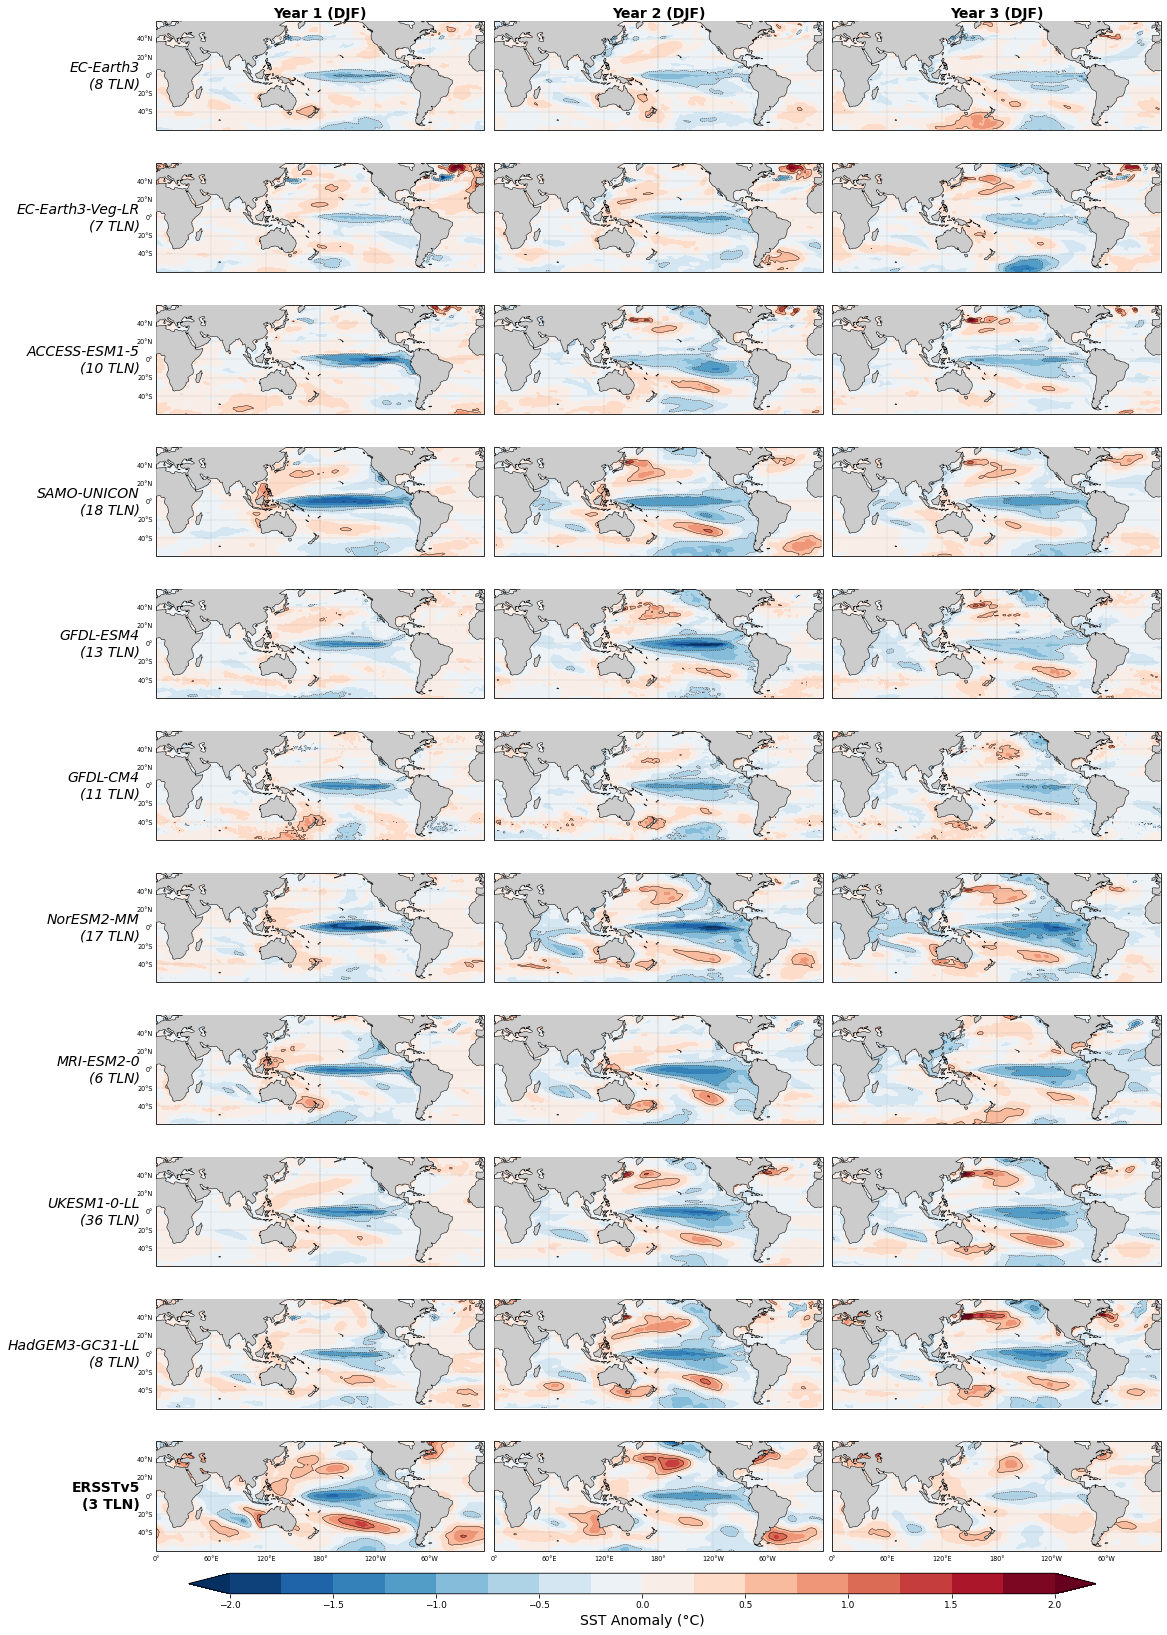

Fig A sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_composites_multimodel.png


In [25]:
models_ok = list(all_sst_composites.keys())
n_models  = len(models_ok)
n_rows    = n_models + 1   # +1 pour ERSSTv5

fig, axes = plt.subplots(
    n_rows, 3,
    figsize=(18, 2.6 * n_rows),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'hspace': 0.06, 'wspace': 0.03}
)

cf_ref = None

# ── Modèles CMIP6 ────────────────────────────────────────────────
for row_i, name in enumerate(models_ok):
    comp  = all_sst_composites[name]
    lat_n = next((c for c in ['nav_lat', 'lat', 'latitude']  if c in comp.coords), comp.dims[-2])
    lon_n = next((c for c in ['nav_lon', 'lon', 'longitude'] if c in comp.coords), comp.dims[-1])
    n_ev  = len(all_tln_years.get(name, []))

    for col_i in range(3):
        ax     = axes[row_i, col_i]
        cyc_d, cyc_l, lat_v = prep_for_plot(comp.isel(offset=col_i), lat_n, lon_n)
        cf_ref = plot_panel(
            ax, cyc_d, cyc_l, lat_v,
            title=YEAR_LABELS[col_i] if row_i == 0 else None,
            gl_left=(col_i == 0),
            gl_bottom=(row_i == n_rows - 1)
        )
        if col_i == 0:
            ax.text(-0.05, 0.5, f'{name}\n({n_ev} TLN)',
                    transform=ax.transAxes, fontsize=14,
                    va='center', ha='right', style='italic')

# ── ERSSTv5 (dernière ligne) ──────────────────────────────────────
for col_i in range(3):
    ax = axes[n_models, col_i]
    if obs_composite is not None:
        cyc_d, cyc_l, lat_v = prep_for_plot(obs_composite.isel(offset=col_i), lat_obs, lon_obs)
        cf_ref = plot_panel(ax, cyc_d, cyc_l, lat_v,
                            gl_left=(col_i == 0), gl_bottom=True)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
    if col_i == 0:
        ax.text(-0.05, 0.5, f'ERSSTv5\n({len(ERSST_TRIPLE_STARTS)} TLN)',
                transform=ax.transAxes, fontsize=14,
                va='center', ha='right', fontweight='bold')

# ── Colorbar ─────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.15, 0.11, 0.70, 0.010])
cb = fig.colorbar(cf_ref, cax=cbar_ax, orientation='horizontal',
                  ticks=np.arange(-2, 2.1, 0.5))
cb.set_label('SST Anomaly (°C)', fontsize=14)
cb.ax.tick_params(labelsize=9)

fig.suptitle(
    'Triple La Niña – DJF SST Anomaly Composites\n',
    fontsize=13, y=1.002, fontweight='bold'
)

path_A = os.path.join(SAVE_DIR, 'TLN_SST_composites_multimodel.png')
plt.savefig(path_A, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig A sauvegardée : {path_A}')

In [26]:
def regrid_to_1deg(da, lat_name, lon_name):
    """Interpole un DataArray 2D [lat, lon] sur la grille commune 1°×1°."""
    lon_vals = da[lon_name].values
    lat_vals = da[lat_name].values
    if lon_vals.ndim == 2:
        pts  = np.column_stack([(lon_vals % 360).ravel(), lat_vals.ravel()])
        vals = da.values.ravel()
        mask = np.isfinite(vals)
        return griddata(pts[mask], vals[mask], (LON2D, LAT2D), method='linear')
    if lon_vals.min() < 0:
        da = da.assign_coords({lon_name: da[lon_name] % 360}).sortby(lon_name)
    return da.interp({lat_name: lat_common, lon_name: lon_common}).values


# Stack modèles
mmm_stack = np.full((len(models_ok), 3, len(lat_common), len(lon_common)), np.nan)
for m_i, name in enumerate(models_ok):
    comp  = all_sst_composites[name]
    lat_n = next((c for c in ['nav_lat', 'lat', 'latitude']  if c in comp.coords), comp.dims[-2])
    lon_n = next((c for c in ['nav_lon', 'lon', 'longitude'] if c in comp.coords), comp.dims[-1])
    for off in range(3):
        try:
            mmm_stack[m_i, off] = regrid_to_1deg(comp.isel(offset=off), lat_n, lon_n)
        except Exception as e:
            print(f'Regrid {name} off={off}: {e}')

mmm = np.nanmean(mmm_stack, axis=0)   # (3, lat, lon)

# ERSSTv5 regridded
obs_regridded = np.full((3, len(lat_common), len(lon_common)), np.nan)
if obs_composite is not None:
    for off in range(3):
        obs_regridded[off] = regrid_to_1deg(
            obs_composite.isel(offset=off), lat_obs, lon_obs
        )

print('MMM shape :', mmm.shape, '| Regridding OK.')

MMM shape : (3, 121, 360) | Regridding OK.


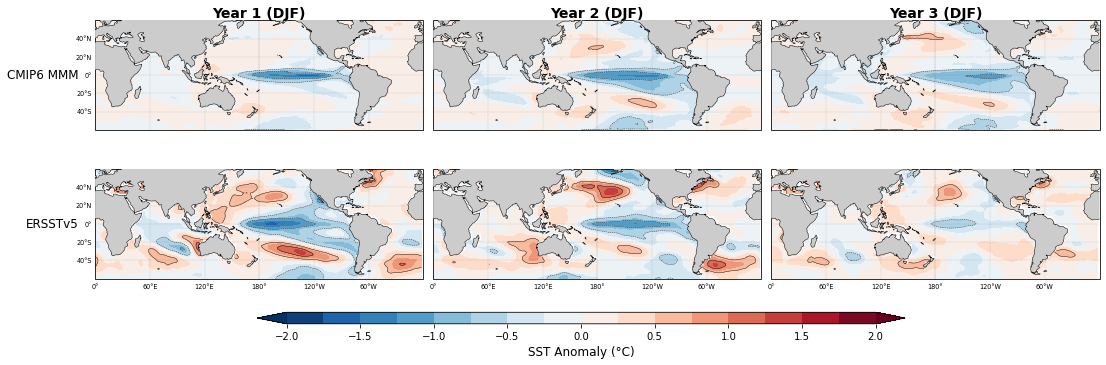

Fig B sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_MMM_vs_obs.png


In [37]:
fig2, axes2 = plt.subplots(
    2, 3,
    figsize=(18, 8),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'hspace': -0.48, 'wspace': 0.03}
)

row_labels   = [f'CMIP6 MMM', 'ERSSTv5']
data_sources = [mmm, obs_regridded]
cf2_ref = None

for row_i, (label, data_3yr) in enumerate(zip(row_labels, data_sources)):
    for col_i in range(3):
        ax    = axes2[row_i, col_i]
        cyc_d, cyc_l = add_cyclic_point(data_3yr[col_i], coord=lon_common)
        cf2_ref = plot_panel(
            ax, cyc_d, cyc_l, lat_common,
            title=YEAR_LABELS[col_i] if row_i == 0 else None,
            gl_left=(col_i == 0),
            gl_bottom=(row_i == 1)
        )
        if col_i == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes,
                    fontsize=12, va='center', ha='right')

cbar_ax2 = fig2.add_axes([0.25, 0.2, 0.50, 0.02])
cb2 = fig2.colorbar(cf2_ref, cax=cbar_ax2, orientation='horizontal',
                    ticks=np.arange(-2, 2.1, 0.5))
cb2.set_label('SST Anomaly (°C)', fontsize=12)
cb2.ax.tick_params(labelsize=10)

fig2.suptitle(
    'Triple La Niña – DJF SST Composites : CMIP6 MMM vs ERSSTv5\n60°S–60°N | centré 180°E',
    fontsize=14, y=1.01, fontweight='bold'
)

path_B = os.path.join(SAVE_DIR, 'TLN_SST_MMM_vs_obs.png')
plt.savefig(path_B, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig B sauvegardée : {path_B}')

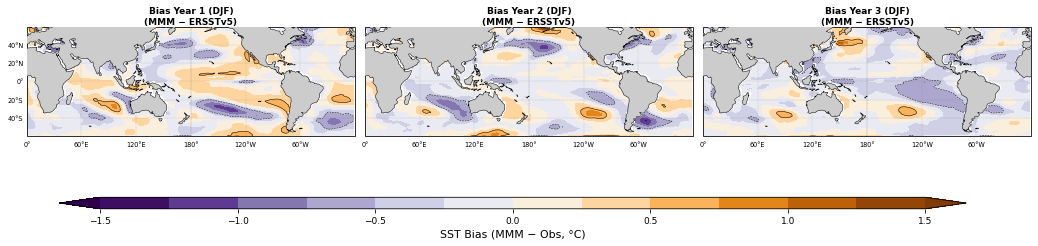

Fig C sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_MMM_bias.png


In [28]:
bias      = mmm - obs_regridded
CLEV_BIAS = np.arange(-1.5, 1.6, 0.25)
NORM_BIAS = mcolors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)

fig3, axes3 = plt.subplots(
    1, 3,
    figsize=(18, 4),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'wspace': 0.03}
)

cf3_ref = None
for col_i in range(3):
    ax    = axes3[col_i]
    cyc_d, cyc_l = add_cyclic_point(bias[col_i], coord=lon_common)
    cf = ax.contourf(
        cyc_l, lat_common, cyc_d,
        levels=CLEV_BIAS, cmap='PuOr_r', norm=NORM_BIAS,
        transform=ccrs.PlateCarree(), extend='both'
    )
    ax.contour(cyc_l, lat_common, cyc_d, levels=[-0.5, 0.5],
               colors='k', linewidths=0.5, linestyles=['--', '-'],
               transform=ccrs.PlateCarree())
    add_map_features(ax, gl_left=(col_i == 0), gl_bottom=True)
    ax.set_title(f'Bias {YEAR_LABELS[col_i]}\n(MMM − ERSSTv5)',
                 fontsize=9, pad=3, fontweight='bold')
    cf3_ref = cf

cbar_ax3 = fig3.add_axes([0.15, 0.06, 0.70, 0.04])
cb3 = fig3.colorbar(cf3_ref, cax=cbar_ax3, orientation='horizontal',
                    ticks=np.arange(-1.5, 1.6, 0.5))
cb3.set_label('SST Bias (MMM − Obs, °C)', fontsize=11)
cb3.ax.tick_params(labelsize=9)

fig3.suptitle(
    'Triple La Niña – SST Bias (CMIP6 MMM − ERSSTv5) | DJF | 60°S–60°N',
    fontsize=13, y=1.05, fontweight='bold'
)

path_C = os.path.join(SAVE_DIR, 'TLN_SST_MMM_bias.png')
plt.savefig(path_C, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig C sauvegardée : {path_C}')

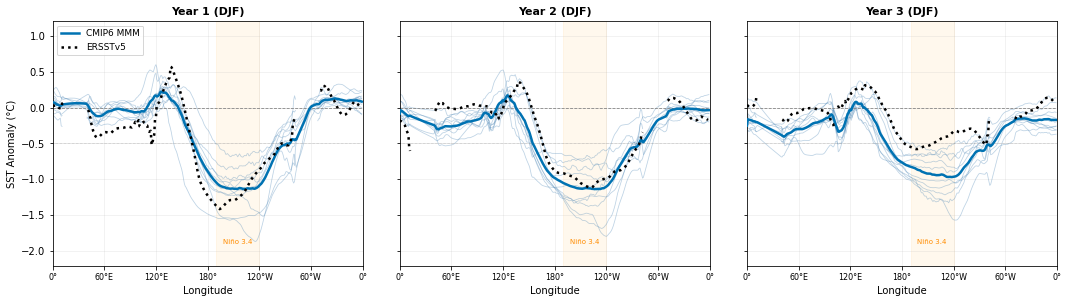

Fig D sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_equatorial_section.png


In [32]:
lat_mask_eq = (lat_common >= -5) & (lat_common <= 5)

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True,
                            gridspec_kw={'wspace': 0.12})

for col_i in range(3):
    ax = axes4[col_i]

    # Modèles individuels
    for m_i in range(len(models_ok)):
        model_eq = np.nanmean(mmm_stack[m_i, col_i][lat_mask_eq, :], axis=0)
        ax.plot(lon_common, model_eq, color='steelblue', lw=0.8, alpha=0.35, zorder=2)

    # MMM
    mmm_eq = np.nanmean(mmm[col_i][lat_mask_eq, :], axis=0)
    ax.plot(lon_common, mmm_eq, color='#0072B2', lw=2.5, label='CMIP6 MMM', zorder=5)

    # ERSSTv5
    obs_eq = np.nanmean(obs_regridded[col_i][lat_mask_eq, :], axis=0)
    ax.plot(lon_common, obs_eq, color='black', lw=2.5, linestyle=':', label='ERSSTv5', zorder=10)

    ax.axhline(0,    color='grey', lw=0.8, linestyle='--')
    ax.axhline(-0.5, color='grey', lw=0.5, linestyle=':')

    for xmin, xmax, zlabel in [(190, 240, 'Niño 3.4')]:
        ax.axvspan(xmin, xmax, alpha=0.07, color='orange', zorder=0)
        ax.text((xmin + xmax) / 2, -1.9, zlabel, ha='center', fontsize=7, color='darkorange')

    ax.set_title(YEAR_LABELS[col_i], fontsize=11, fontweight='bold')
    ax.set_xlim(0, 360)
    ax.set_ylim(-2.2, 1.2)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
    ax.set_xticklabels(['0°', '60°E', '120°E', '180°', '120°W', '60°W', '0°'], fontsize=8)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    if col_i == 0:
        ax.set_ylabel('SST Anomaly (°C)', fontsize=10)
        ax.legend(fontsize=9, loc='upper left')

fig4.suptitle(
    'Triple La Niña – Equatorial SST Anomaly (5°S–5°N) | DJF',
    fontsize=13, fontweight='bold', y=1.02
)

path_D = os.path.join(SAVE_DIR, 'TLN_SST_equatorial_section.png')
plt.savefig(path_D, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig D sauvegardée : {path_D}')

In [30]:
# ================================================================
# CALCUL DES COMPOSITES SAISONNIERS : JJA, SON, DJF
# Pour chaque modèle CMIP6 et ERSSTv5
# ================================================================

SEASONS = {
    'JJA': [6, 7, 8],    # Juin-Juil-Août  → tous dans la même année yr+offset
    'SON': [9, 10, 11],  # Sep-Oct-Nov     → tous dans la même année yr+offset
    'DJF': [12, 1, 2],   # Déc-Jan-Fév     → Déc(yr+offset) + Jan-Fév(yr+offset+1)
}

def extract_seasonal_mean(ds_field, yr_base, offset, season_months):
    """
    Extrait la moyenne saisonnière d'anomalies depuis un champ [time, lat, lon].
    Pour DJF : Déc(yr_base+offset) + Jan-Fév(yr_base+offset+1)
    Pour JJA/SON : les 3 mois sont dans yr_base+offset
    """
    target_yr = yr_base + offset
    maps = []
    for m in season_months:
        if m in [1, 2] and season_months[0] == 12:
            # DJF : Jan et Fév appartiennent à l'année suivante
            y = target_yr + 1
        else:
            y = target_yr
        m_data = ds_field.where(
            (ds_field['time.year'] == y) & (ds_field['time.month'] == m),
            drop=True
        ).mean('time')
        maps.append(m_data)
    return sum(maps) / len(maps)


# ── Composites saisonniers CMIP6 (depuis les fichiers bruts) ─────
# On relit chaque modèle pour extraire JJA et SON en plus de DJF
# (DJF est déjà dans all_sst_composites mais on le recalcule ici
#  pour uniformiser la structure)

all_seasonal_composites = {s: {} for s in SEASONS}  
# {saison: {model: np.array [3, lat_common, lon_common]}}

print('Recalcul des composites saisonniers CMIP6...')

for name, path in cmip6_models.items():
    if name not in all_tln_years or len(all_tln_years[name]) == 0:
        continue
    if not os.path.exists(path):
        continue

    print(f'  {name}')
    try:
        ds = xr.open_mfdataset(path + '*.nc', combine='by_coords',
                               chunks={'time': 240}, use_cftime=True)
        lat_n = next((c for c in ['nav_lat','lat','latitude']  if c in ds.coords or c in ds.data_vars), None)
        lon_n = next((c for c in ['nav_lon','lon','longitude'] if c in ds.coords or c in ds.data_vars), None)

        mask_lat = ((ds[lat_n] >= -60) & (ds[lat_n] <= 60)).compute()
        ds_tos   = ds.tos.where(mask_lat, drop=True)
        if float(ds_tos.isel(time=0).mean().compute()) > 100:
            ds_tos = ds_tos - 273.15

        clim_monthly = ds_tos.groupby('time.month').mean('time').compute()

        for season, months in SEASONS.items():
            # Climatologie saisonnière
            seas_clim = sum(clim_monthly.sel(month=m) for m in months) / len(months)

            event_composites = []
            for yr in all_tln_years[name]:
                offset_maps = []
                ok = True
                for off in range(3):
                    try:
                        raw = extract_seasonal_mean(ds_tos, yr, off, months)
                        raw = raw.compute()
                        anom = raw - seas_clim
                        # Regrid → grille commune 1°×1°
                        anom_1deg = regrid_to_1deg(anom, lat_n, lon_n)
                        offset_maps.append(anom_1deg)
                    except Exception as e:
                        print(f'    {season} off={off} yr={yr}: {e}')
                        ok = False; break
                if ok and len(offset_maps) == 3:
                    event_composites.append(np.stack(offset_maps, axis=0))  # (3, lat, lon)

            if event_composites:
                all_seasonal_composites[season][name] = np.nanmean(
                    np.stack(event_composites, axis=0), axis=0
                )  # (3, lat_common, lon_common)

        ds.close()
    except Exception as e:
        print(f'  ERREUR {name}: {e}')

# ── Composites saisonniers ERSSTv5 ───────────────────────────────
print('\nComposites saisonniers ERSSTv5...')
obs_seasonal_composites = {}   # {saison: np.array [3, lat, lon]}

for season, months in SEASONS.items():
    event_composites = []
    for yr in ERSST_TRIPLE_STARTS:
        offset_maps = []
        ok = True
        for off in range(3):
            try:
                raw_anom = extract_seasonal_mean(ds_obs_anom, yr, off, months)
                raw_anom = raw_anom.compute()
                # Regrid → grille commune
                anom_1deg = regrid_to_1deg(raw_anom, lat_obs, lon_obs)
                offset_maps.append(anom_1deg)
            except Exception as e:
                print(f'  ERSSTv5 {season} off={off} yr={yr}: {e}')
                ok = False; break
        if ok and len(offset_maps) == 3:
            event_composites.append(np.stack(offset_maps, axis=0))

    if event_composites:
        obs_seasonal_composites[season] = np.nanmean(
            np.stack(event_composites, axis=0), axis=0
        )  # (3, lat_common, lon_common)

# ── MMM par saison ───────────────────────────────────────────────
mmm_seasonal = {}   # {saison: np.array [3, lat, lon]}
for season in SEASONS:
    models_s = list(all_seasonal_composites[season].keys())
    if models_s:
        stack = np.stack([all_seasonal_composites[season][m] for m in models_s], axis=0)
        mmm_seasonal[season] = np.nanmean(stack, axis=0)
    print(f'  {season} : {len(models_s)} modèles')

print('Calcul saisonnier terminé.')

Recalcul des composites saisonniers CMIP6...
  EC-Earth3
  EC-Earth3-Veg-LR
  ACCESS-ESM1-5
  SAMO-UNICON
  GFDL-ESM4
  GFDL-CM4
  NorESM2-MM
  MRI-ESM2-0
  UKESM1-0-LL
  HadGEM3-GC31-LL

Composites saisonniers ERSSTv5...
  JJA : 10 modèles
  SON : 10 modèles
  DJF : 10 modèles
Calcul saisonnier terminé.


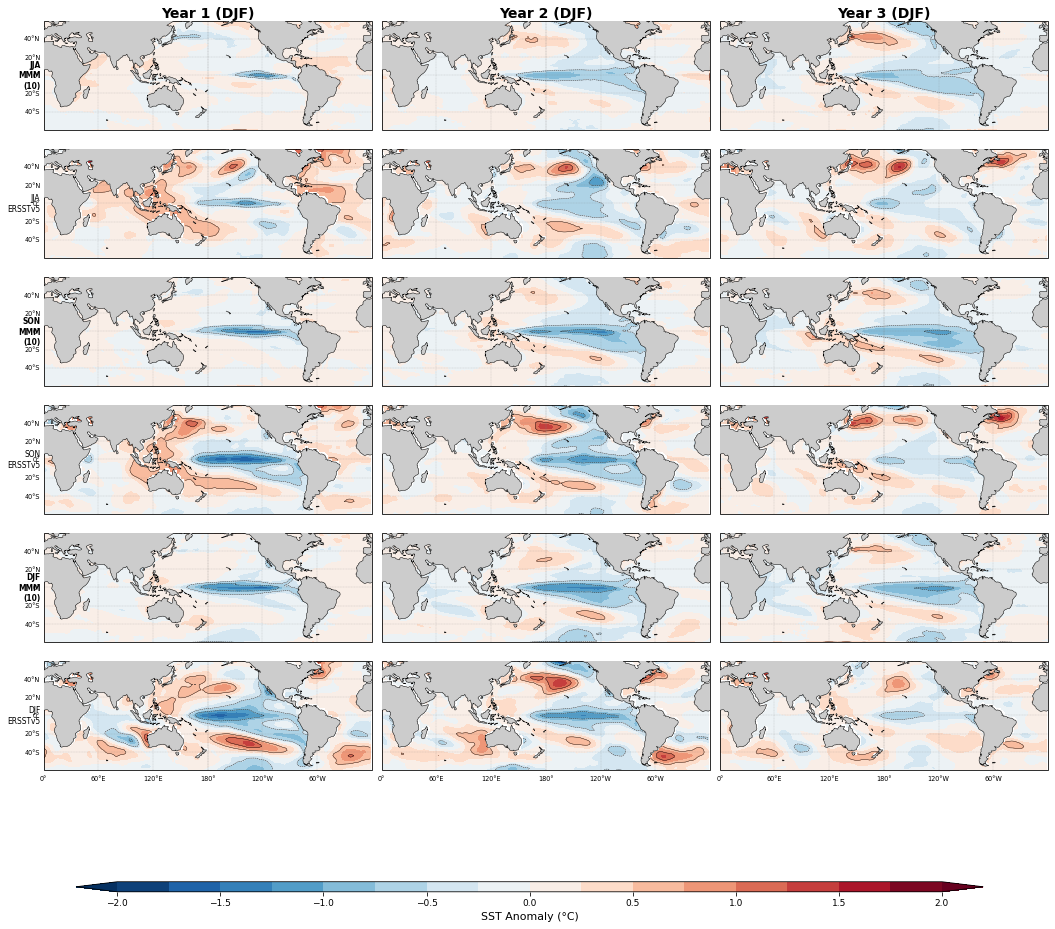

Fig E sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_seasonal_MMM_vs_obs.png


In [31]:
# ================================================================
# FIGURE E – MMM vs ERSSTv5 : JJA / SON / DJF × Year 1/2/3
# Layout : 6 lignes × 3 colonnes
#   Ligne 0 : JJA MMM
#   Ligne 1 : JJA ERSSTv5
#   Ligne 2 : SON MMM
#   Ligne 3 : SON ERSSTv5
#   Ligne 4 : DJF MMM
#   Ligne 5 : DJF ERSSTv5
# ================================================================

season_list  = ['JJA', 'SON', 'DJF']
n_models_mmm = len(models_ok)

fig5, axes5 = plt.subplots(
    6, 3,
    figsize=(18, 14),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'hspace': 0.06, 'wspace': 0.03}
)

cf5_ref = None

for s_i, season in enumerate(season_list):
    mmm_s = mmm_seasonal.get(season)
    obs_s = obs_seasonal_composites.get(season)

    for col_i in range(3):

        # ── Ligne MMM ──────────────────────────────────────────
        ax_mmm = axes5[s_i * 2, col_i]
        if mmm_s is not None:
            cyc_d, cyc_l = add_cyclic_point(mmm_s[col_i], coord=lon_common)
            cf5_ref = plot_panel(
                ax_mmm, cyc_d, cyc_l, lat_common,
                title=YEAR_LABELS[col_i] if s_i == 0 else None,
                gl_left=(col_i == 0),
                gl_bottom=False
            )
        if col_i == 0:
            ax_mmm.text(-0.01, 0.5,
                        f'{season}\nMMM\n({n_models_mmm})',
                        transform=ax_mmm.transAxes,
                        fontsize=7.5, va='center', ha='right', fontweight='bold')

        # ── Ligne ERSSTv5 ───────────────────────────────────────
        ax_obs = axes5[s_i * 2 + 1, col_i]
        if obs_s is not None:
            cyc_d, cyc_l = add_cyclic_point(obs_s[col_i], coord=lon_common)
            cf5_ref = plot_panel(
                ax_obs, cyc_d, cyc_l, lat_common,
                gl_left=(col_i == 0),
                gl_bottom=(s_i == 2)   # labels bas uniquement sur la dernière saison
            )
        if col_i == 0:
            ax_obs.text(-0.01, 0.5,
                        f'{season}\nERSSTv5',
                        transform=ax_obs.transAxes,
                        fontsize=7.5, va='center', ha='right')

        # Ligne de séparation visuelle entre saisons (via espacement)
        # → géré par hspace, mais on peut ajouter un trait avec annotate si besoin

# ── Colorbar ─────────────────────────────────────────────────────
cbar_ax5 = fig5.add_axes([0.15, 0.01, 0.70, 0.010])
cb5 = fig5.colorbar(cf5_ref, cax=cbar_ax5, orientation='horizontal',
                    ticks=np.arange(-2, 2.1, 0.5))
cb5.set_label('SST Anomaly (°C)', fontsize=11)
cb5.ax.tick_params(labelsize=9)

fig5.suptitle(
    'Triple La Niña – Seasonal SST Anomaly Composites\n'
    'CMIP6 MMM vs ERSSTv5 | JJA / SON / DJF | 60°S–60°N | centré 180°E',
    fontsize=13, y=1.002, fontweight='bold'
)

path_E = os.path.join(SAVE_DIR, 'TLN_SST_seasonal_MMM_vs_obs.png')
plt.savefig(path_E, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig E sauvegardée : {path_E}')

In [38]:
# ================================================================
# Définition des saisons et règles d'extraction
# Chaque entrée : (mois, décalage_année_relatif_à_target_yr)
# target_yr = yr_event + offset  (offset = 0→Année1, 1→Année2, 2→Année3)
# ================================================================

# Format : {saison: [(mois, delta_yr), ...]}
# delta_yr = 0 → mois dans target_yr
# delta_yr = 1 → mois dans target_yr + 1
SEASON_DEFS = {
    'JJA': [(6, 0), (7, 0), (8, 0)],
    'SON': [(9, 0), (10, 0), (11, 0)],
    'DJF': [(12, 0), (1, 1), (2, 1)],
    'MAM': [(3, 1), (4, 1), (5, 1)],
}
SEASON_ORDER = ['JJA', 'SON', 'DJF', 'MAM']


def get_monthly_mean(ds_field, year, month):
    """Extrait la moyenne d'un mois donné depuis un champ [time, ...]. Robuste aux index vides."""
    mask = (ds_field['time.year'] == year) & (ds_field['time.month'] == month)
    sub  = ds_field.isel(time=mask.values)
    if sub.sizes['time'] == 0:
        raise ValueError(f'Aucun timestep pour {year}-{month:02d}')
    return sub.mean('time')


def seasonal_anom_cmip(ds_tos, clim_monthly, yr_event, offset, season_def):
    """
    Calcule l'anomalie saisonnière pour un modèle CMIP6 (piControl).
    ds_tos       : DataArray brut SST [time, lat, lon]
    clim_monthly : DataArray climatologie mensuelle [month, lat, lon]
    yr_event     : année de début du TLN
    offset       : 0=Année1, 1=Année2, 2=Année3
    season_def   : liste [(mois, delta_yr), ...]
    """
    target_yr = yr_event + offset
    maps_raw, maps_clim = [], []
    for (m, dy) in season_def:
        y = target_yr + dy
        maps_raw.append(get_monthly_mean(ds_tos, y, m).compute())
        maps_clim.append(clim_monthly.sel(month=m))
    raw_mean  = sum(maps_raw)  / len(maps_raw)
    clim_mean = sum(maps_clim) / len(maps_clim)
    return raw_mean - clim_mean


def seasonal_anom_obs(ds_anom, yr_event, offset, season_def):
    """
    Calcule l'anomalie saisonnière ERSSTv5 (déjà detrendée NOAA-style).
    ds_anom  : champ d'anomalies [time, lat, lon] → pas de clim à soustraire
    """
    target_yr = yr_event + offset
    maps = []
    for (m, dy) in season_def:
        y = target_yr + dy
        maps.append(get_monthly_mean(ds_anom, y, m).compute())
    return sum(maps) / len(maps)


# ── CMIP6 : composites saisonniers sur grille commune 1°×1° ──────
# Structure : {saison: {model: np.array [3, lat_common, lon_common]}}
all_seasonal = {s: {} for s in SEASON_ORDER}

print('Calcul des composites saisonniers CMIP6...')
for name, path in cmip6_models.items():
    if name not in all_tln_years or len(all_tln_years[name]) == 0:
        continue
    if not os.path.exists(path):
        continue
    print(f'  {name}')
    try:
        ds    = xr.open_mfdataset(path + '*.nc', combine='by_coords',
                                   chunks={'time': 240}, use_cftime=True)
        lat_n = next((c for c in ['nav_lat','lat','latitude']  if c in ds.coords or c in ds.data_vars), None)
        lon_n = next((c for c in ['nav_lon','lon','longitude'] if c in ds.coords or c in ds.data_vars), None)
        mask_lat = ((ds[lat_n] >= -60) & (ds[lat_n] <= 60)).compute()
        ds_tos   = ds.tos.where(mask_lat, drop=True)
        if float(ds_tos.isel(time=0).mean().compute()) > 100:
            ds_tos = ds_tos - 273.15
        clim_monthly = ds_tos.groupby('time.month').mean('time').compute()

        for season in SEASON_ORDER:
            sdef = SEASON_DEFS[season]
            event_maps = []   # [n_events, 3, lat, lon]
            for yr in all_tln_years[name]:
                offset_maps = []
                ok = True
                for off in range(3):
                    try:
                        anom   = seasonal_anom_cmip(ds_tos, clim_monthly, yr, off, sdef)
                        anom1d = regrid_to_1deg(anom, lat_n, lon_n)
                        offset_maps.append(anom1d)
                    except Exception as e:
                        print(f'    {season} off={off} yr={yr}: {e}')
                        ok = False; break
                if ok:
                    event_maps.append(np.stack(offset_maps))   # (3, lat, lon)
            if event_maps:
                all_seasonal[season][name] = np.nanmean(np.stack(event_maps), axis=0)
        ds.close()
    except Exception as e:
        print(f'  ERREUR {name}: {e}')

# MMM par saison
mmm_seasonal = {}
for season in SEASON_ORDER:
    mods = list(all_seasonal[season].keys())
    if mods:
        mmm_seasonal[season] = np.nanmean(np.stack([all_seasonal[season][m] for m in mods]), axis=0)
    print(f'  MMM {season} : {len(mods)} modèles')

# ── ERSSTv5 : composites saisonniers ─────────────────────────────
# Années de début observées : yr0=1973/1998/2020
# (déjà dans ERSST_TRIPLE_STARTS)
print('\nComposites saisonniers ERSSTv5...')
obs_seasonal = {}

for season in SEASON_ORDER:
    sdef = SEASON_DEFS[season]
    event_maps = []
    for yr in ERSST_TRIPLE_STARTS:
        offset_maps = []
        ok = True
        for off in range(3):
            try:
                anom   = seasonal_anom_obs(ds_obs_anom, yr, off, sdef)
                anom1d = regrid_to_1deg(anom, lat_obs, lon_obs)
                offset_maps.append(anom1d)
            except Exception as e:
                print(f'  ERSSTv5 {season} off={off} yr={yr}: {e}')
                ok = False; break
        if ok:
            event_maps.append(np.stack(offset_maps))
    if event_maps:
        obs_seasonal[season] = np.nanmean(np.stack(event_maps), axis=0)
        print(f'  {season} OK : shape={obs_seasonal[season].shape}')

print('\nComposites saisonniers terminés.')

Calcul des composites saisonniers CMIP6...
  EC-Earth3
  EC-Earth3-Veg-LR
  ACCESS-ESM1-5
  SAMO-UNICON
  GFDL-ESM4
  GFDL-CM4
  NorESM2-MM
  MRI-ESM2-0
  UKESM1-0-LL
  HadGEM3-GC31-LL
  MMM JJA : 10 modèles
  MMM SON : 10 modèles
  MMM DJF : 10 modèles
  MMM MAM : 10 modèles

Composites saisonniers ERSSTv5...
  JJA OK : shape=(3, 121, 360)
  SON OK : shape=(3, 121, 360)
  DJF OK : shape=(3, 121, 360)
  MAM OK : shape=(3, 121, 360)

Composites saisonniers terminés.


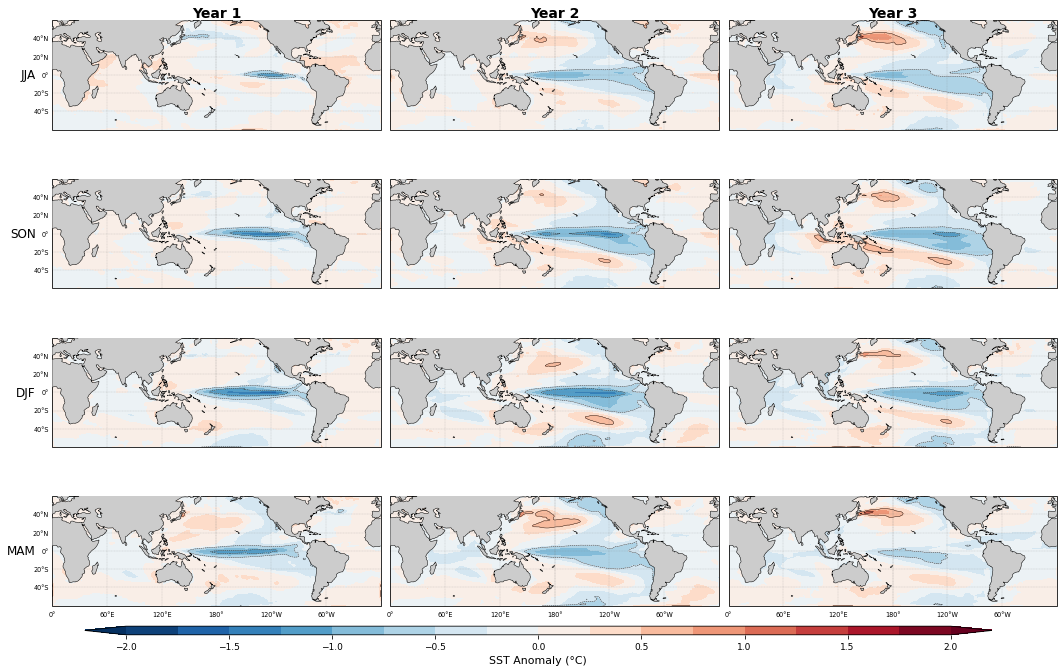

Fig E sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_seasonal_development_MMM.png


In [46]:
# Labels de colonnes : Year 1, Year 2, Year 3
# Labels de lignes   : saison + années concernées
# Pour les labels de ligne on montre l'exemple ERSSTv5 (yr0=1998)
ROW_LABELS_MMM = [
    'JJA',
    'SON',
    'DJF',
    'MAM',
]
COL_LABELS = ['Year 1', 'Year 2', 'Year 3']
n_models_s  = len(models_ok)

fig_E, axes_E = plt.subplots(
    4, 3,
    figsize=(18, 12),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'hspace': -0.1, 'wspace': 0.03}
)

cfE_ref = None
for row_i, season in enumerate(SEASON_ORDER):
    data_s = mmm_seasonal.get(season)   # (3, lat, lon)
    for col_i in range(3):
        ax = axes_E[row_i, col_i]
        if data_s is not None:
            cyc_d, cyc_l = add_cyclic_point(data_s[col_i], coord=lon_common)
            cfE_ref = plot_panel(
                ax, cyc_d, cyc_l, lat_common,
                title=COL_LABELS[col_i] if row_i == 0 else None,
                gl_left=(col_i == 0),
                gl_bottom=(row_i == 3)
            )
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes)
        # Label de ligne à gauche
        if col_i == 0:
            ax.text(-0.05, 0.5, ROW_LABELS_MMM[row_i],
                    transform=ax.transAxes,
                    fontsize=12, va='center', ha='right')

# Colorbar
cbarE = fig_E.add_axes([0.15, 0.13, 0.70, 0.010])
cbE   = fig_E.colorbar(cfE_ref, cax=cbarE, orientation='horizontal',
                        ticks=np.arange(-2, 2.1, 0.5))
cbE.set_label('SST Anomaly (°C)', fontsize=11)
cbE.ax.tick_params(labelsize=9)

fig_E.suptitle(
    f'Triple La Niña – Seasonal SST Development | CMIP6 MMM ({n_models_s} models)\n'
    '60°S–60°N | centré 180°E | piControl',
    fontsize=13, y=1.002, fontweight='bold'
)

path_E = os.path.join(SAVE_DIR, 'TLN_SST_seasonal_development_MMM.png')
plt.savefig(path_E, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig E sauvegardée : {path_E}')

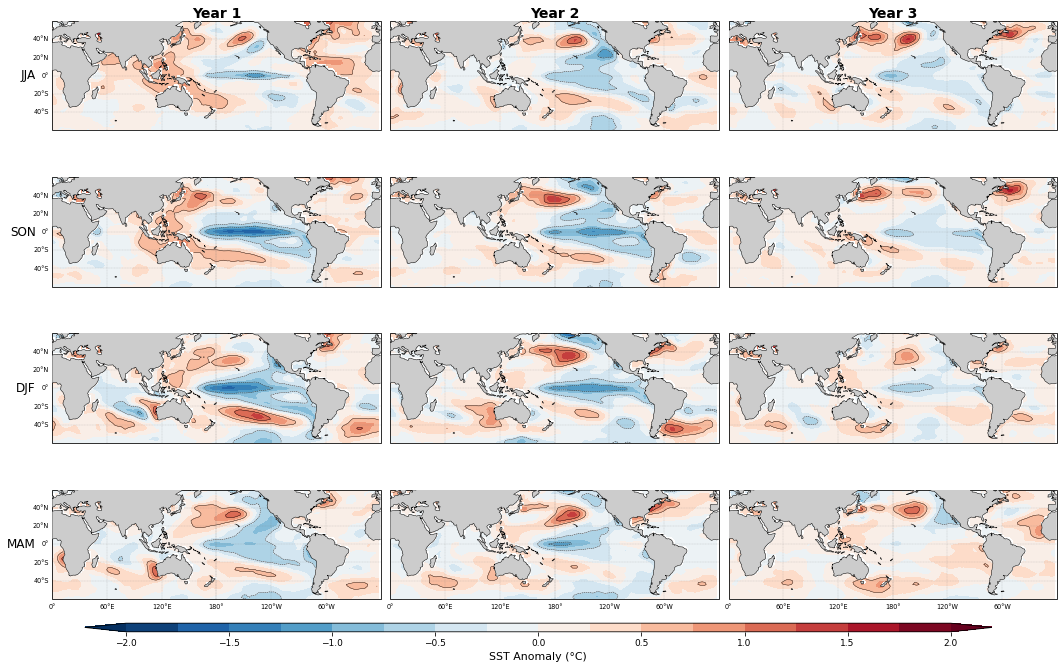

Fig F sauvegardée : /g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sst/TLN_SST_seasonal_development_ERSSTv5.png


In [44]:
# Labels de ligne ERSSTv5 avec les années explicites
# yr0 = [1973, 1998, 2020] → yr0+off pour off=0,1,2
_y = ERSST_TRIPLE_STARTS   # [1973, 1998, 2020]

def yr_str(base_list, delta):
    """Formate une liste d'années ex: [1973,1998,2020]+1 → '74/99/21'"""
    return '/'.join(str(b + delta)[-2:] for b in base_list)

ROW_LABELS_OBS = [
    f"JJA",
    f"SON",
    f"DJF",
    f"MAM",
]

# Titres de colonnes avec les années Year1/Year2/Year3
COL_LABELS_OBS = [
    f'Year 1',
    f'Year 2',
    f'Year 3',
]

fig_F, axes_F = plt.subplots(
    4, 3,
    figsize=(18, 12),
    subplot_kw={'projection': PROJ},
    gridspec_kw={'hspace': -0.15, 'wspace': 0.03}
)

cfF_ref = None
for row_i, season in enumerate(SEASON_ORDER):
    data_s = obs_seasonal.get(season)   # (3, lat, lon)
    for col_i in range(3):
        ax = axes_F[row_i, col_i]
        if data_s is not None:
            cyc_d, cyc_l = add_cyclic_point(data_s[col_i], coord=lon_common)
            cfF_ref = plot_panel(
                ax, cyc_d, cyc_l, lat_common,
                title=COL_LABELS_OBS[col_i] if row_i == 0 else None,
                gl_left=(col_i == 0),
                gl_bottom=(row_i == 3)
            )
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes)
        if col_i == 0:
            ax.text(-0.05, 0.5, ROW_LABELS_OBS[row_i],
                    transform=ax.transAxes,
                    fontsize=12, va='center', ha='right')

# Colorbar
cbarF = fig_F.add_axes([0.15, 0.13, 0.70, 0.010])
cbF   = fig_F.colorbar(cfF_ref, cax=cbarF, orientation='horizontal',
                        ticks=np.arange(-2, 2.1, 0.5))
cbF.set_label('SST Anomaly (°C)', fontsize=11)
cbF.ax.tick_params(labelsize=9)

n_obs_ev = len(ERSST_TRIPLE_STARTS)
fig_F.suptitle(
    f'Triple La Niña – Seasonal SST Development | ERSSTv5 ({n_obs_ev} events)\n'
    f'yr0 = {", ".join(str(y) for y in ERSST_TRIPLE_STARTS)} | 60°S–60°N | centré 180°E',
    fontsize=13, y=1.002, fontweight='bold'
)

path_F = os.path.join(SAVE_DIR, 'TLN_SST_seasonal_development_ERSSTv5.png')
plt.savefig(path_F, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Fig F sauvegardée : {path_F}')